In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import math

In [17]:
gold_returns = """
1968	18.8
1969	-16.07
1970	6.16
1971	16.37
1972	48.74
1973	73.49
1974	67.04
1975	-25.2
1976	-4.06
1977	23.08
1978	35.57
1979	133.41
1980	12.5
1981	-32.15
1982	12
1983	-14.84
1984	-19
1985	5.83
1986	19.54
1987	24.46
1988	-15.69
1989	-2.23
1990	-2.49
1991	-9.62
1992	-5.8
1993	17.35
1994	-2.09
1995	1.1
1996	-4.43
1997	-21.74
1998	-0.61
1999	1.18
2000	-6.26
2001	1.41
2002	23.96
2003	21.74
2004	4.97
2005	17.12
2006	23.92
2007	31.59
2008	3.41
2009	27.63
2010	27.74
2011	11.65
2012	5.68
2013	-27.79
2014	-0.19
2015	-11.59
2016	8.63
2017	12.57
2018	-1.15
2019	18.83
2020	24.43
2021	-3.51
2022	-0.23
2023	13.08
2024	27.23
2025	64.69
"""

spx_returns = """
2025	 17.88
2024	 25.02
2023	 26.29
2022	-18.11
2021	 28.83
2020	 18.38
2019	 31.74
2018	 -4.41
2017	 21.94
2016	 11.93
2015	  1.31
2014	 13.81
2013	 32.43
2012	 15.88
2011	  2.07
2010	 14.87
2009	 27.11
2008	-37.22
2007	  5.46
2006	 15.74
2005	  4.79
2004	 10.82
2003	 28.72
2002	-22.27
2001	-11.98
2000	 -9.11
1999	 21.11
1998	 28.73
1997	 33.67
1996	 23.06
1995	 38.02
1994	  1.19
1993	 10.17
1992	  7.60
1991	 30.95
1990	 -3.42
1989	 32.00
1988	 16.64
1987	  5.69
1986	 19.06
1985	 32.24
1984	  5.96
1983	 23.13
1982	 21.22
1981	 -5.33
1980	 32.76
1979	 18.69
1978	  6.41
1977	 -7.78
1976	 24.20
1975	 38.46
1974	-26.95
1973	-15.03
1972	 19.15
1971	 14.54
1970	  3.60
1969	 -8.63
1968	 11.03
1967	 24.45
1966	-10.36
1965	 12.45
1964	 16.59
1963	 23.04
1962	 -9.20
1961	 28.51
1960	 -0.74
1959	 11.59
1958	 43.40
1957	 -9.30
1956	  6.38
1955	 28.22
1954	 55.99
1953	 -0.80
1952	 18.35
1951	 23.10
1950	 34.28
1949	 15.96
1948	  9.51
1947	  2.56
1946	-12.05
1945	 39.35
1944	 19.67
1943	 23.60
1942	 21.74
1941	 -9.09
1940	 -8.91
1939	  2.98
1938	 17.50
1937	-32.11
1936	 32.55
1935	 54.93
1934	 -8.01
1933	 56.79
1932	 -5.81
1931	-44.20
1930	-22.72
1929	 -9.46
1928	 47.57
1927	 37.10
1926	 11.51
1925	 25.83
1924	 27.10
1923	  5.45
1922	 29.07
1921	 10.15
1920	-13.95
1919	 19.67
1918	 18.21
1917	-18.62
1916	  8.12
1915	 31.20
1914	 -5.39
1913	 -4.73
1912	  7.18
1911	  3.52
1910	 -3.39
1909	 16.15
1908	 39.47
1907	-24.21
1906	  0.64
1905	 21.29
1904	 32.16
1903	-17.09
1902	  8.28
1901	 19.45
"""

gold_annual_returns = {}
for row in gold_returns.split('\n'):
    if not row.strip():
        continue
    year, r = row.split()
    gold_annual_returns[year.strip()] = float(r.strip()) / 100

sp_annual_returns = {}
for row in spx_returns.split('\n'):
    if not row.strip():
        continue
    year, r = row.split()
    sp_annual_returns[year.strip()] = float(r.strip()) / 100

all_spxs = np.asarray(list(sp_annual_returns.values()))

spxs = []
golds = []
for year, sv in sp_annual_returns.items():
    if not gold_annual_returns.get(year):
        continue
    spxs.append(sv)
    golds.append(gold_annual_returns[year])

spxs = np.asarray(spxs)
golds = np.asarray(golds)


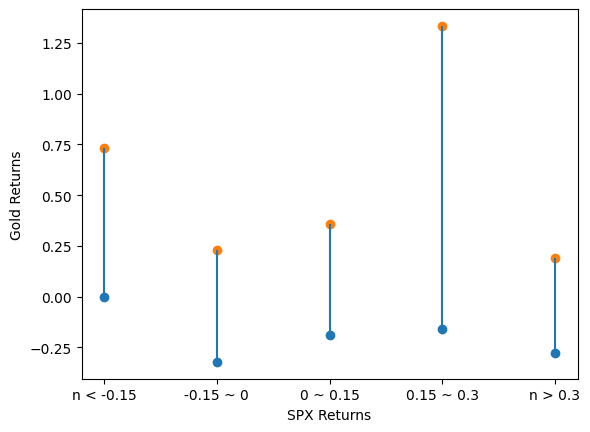

In [18]:
gold_spx_bins = [
    golds[spxs < -0.15],
    golds[(spxs >= -0.15) & (spxs < 0)],
    golds[(spxs >= 0) & (spxs < 0.15)],
    golds[(spxs >= 0.15) & (spxs <= 0.3)],
    golds[spxs > 0.3]
]

labels = ['n < -0.15', '-0.15 ~ 0', '0 ~ 0.15', '0.15 ~ 0.3', 'n > 0.3']
x = np.arange(len(gold_spx_bins))

m_min = [vals.min() if len(vals) > 0 else np.nan for vals in gold_spx_bins]
m_max = [vals.max() if len(vals) > 0 else np.nan for vals in gold_spx_bins]

plt.vlines(x, m_min, m_max)
plt.scatter(x, m_min)
plt.scatter(x, m_max)

plt.xticks(x, labels)
plt.ylabel('Gold Returns')
plt.xlabel('SPX Returns')
plt.show()


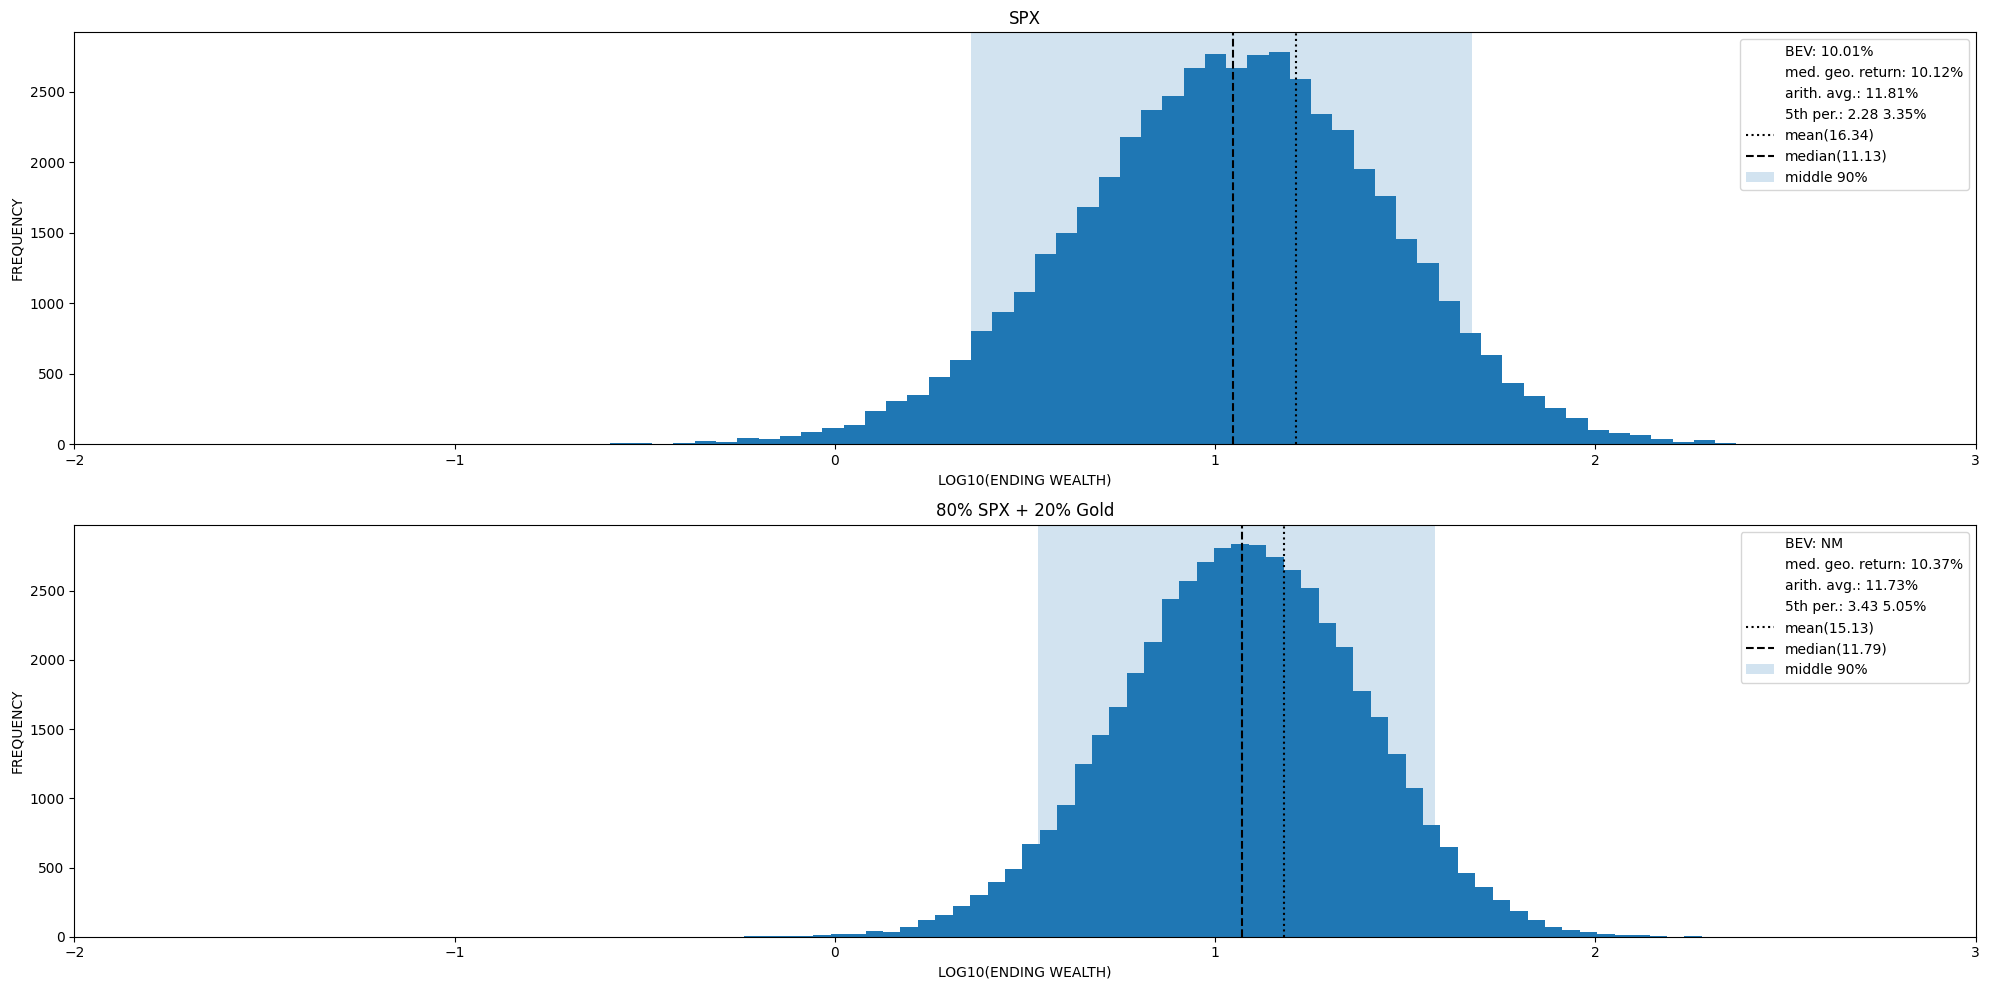

In [19]:
payoffs = np.asarray(all_spxs)

samples = 50000
bets = 25

random_paths = np.random.randint(0, len(payoffs), (samples, bets))

fig, (subfig1, subfig2) = plt.subplots(2, 1, figsize=(20, 10))

# ------- All In
ending_wealths = np.prod(1 + payoffs[random_paths], axis=1)
mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
bev = np.exp(np.mean(np.log(1+payoffs))) - 1
median_geometric_return = median ** (1 / bets) - 1

arithmetic_avg = np.mean(1 + payoffs) - 1

subfig1.hist(ending_wealth_log, bins=60)
subfig1.set_xlim(-2, 3)
# legend-only text entries
subfig1.plot([], [], ' ', label=f'BEV: {bev:.2%}')
subfig1.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig1.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg * 100:.2f}%')
subfig1.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f} {(np.power(np.power(10, p5), 1/bets) - 1)* 100:.2f}%')

subfig1.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig1.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig1.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig1.set_title("SPX")
subfig1.set_xlabel("LOG10(ENDING WEALTH)")
subfig1.set_ylabel("FREQUENCY")
subfig1.legend()

# ------- 20% gold
gold_ratio = 0.20

spx_payoffs = payoffs[random_paths]

bin_indices = np.select(
    [
        spx_payoffs < -0.15,
        (spx_payoffs >= -0.15) & (spx_payoffs < 0),
        (spx_payoffs >= 0) & (spx_payoffs < 0.15),
        (spx_payoffs >= 0.15) & (spx_payoffs <= 0.3),
        spx_payoffs > 0.3
    ],
    [0, 1, 2, 3, 4]
)

gold_payoffs = []
for path in bin_indices:
    gold_payoffs.append([np.random.choice(gold_spx_bins[idx]) for idx in path])

gold_payoffs = np.asarray(gold_payoffs)

ending_wealths = np.prod(
    (1-gold_ratio) * (1 + payoffs[random_paths]) + gold_ratio * (1+gold_payoffs),
    axis=1)

mean = np.mean(ending_wealths)
median = np.median(ending_wealths)
ending_wealth_log = np.log10(ending_wealths)

p5, p95 = np.percentile(ending_wealth_log, [5, 95])
median_geometric_return = median ** (1 / bets) - 1
arithmetic_avg = np.mean(payoffs) * (1- gold_ratio) + np.mean(golds) * gold_ratio

subfig2.hist(ending_wealth_log, bins=60)
subfig2.set_xlim(-2, 3)
# legend-only text entries
subfig2.plot([], [], ' ', label=f'BEV: NM')
subfig2.plot([], [], ' ', label=f'med. geo. return: {median_geometric_return:.2%}')
subfig2.plot([], [], ' ', label=f'arith. avg.: {arithmetic_avg:.2%}')
subfig2.plot([], [], ' ', label=f'5th per.: {np.power(10, p5):.2f} {(np.power(np.power(10, p5), 1/bets) - 1)* 100:.2f}%')

subfig2.axvline(np.log10(mean), linestyle='dotted', color='black', label=f'mean({mean:.2f})')
subfig2.axvline(np.log10(median), linestyle='dashed', color='black', label=f'median({median:.2f})')
subfig2.axvspan(p5, p95, alpha=0.2, label="middle 90%")

subfig2.set_title("80% SPX + 20% Gold")
subfig2.set_xlabel("LOG10(ENDING WEALTH)")
subfig2.set_ylabel("FREQUENCY")
subfig2.legend()

fig.tight_layout()
plt.show()

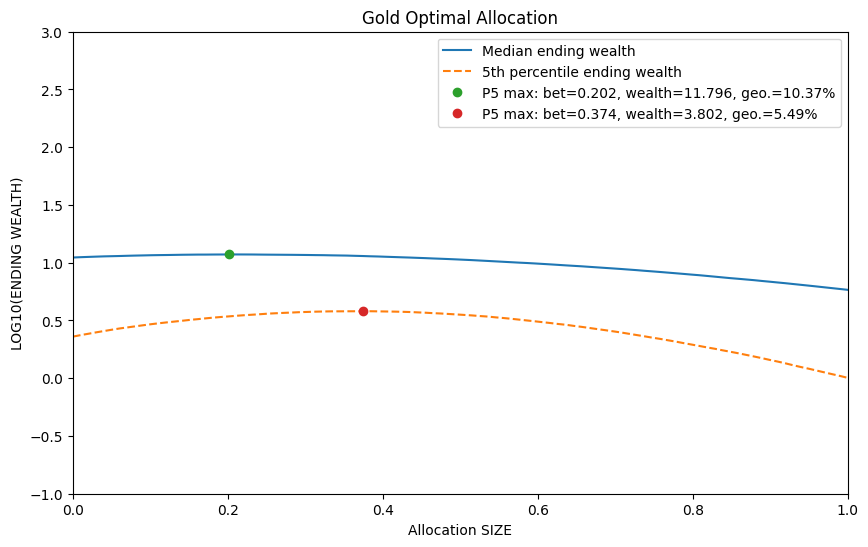

In [24]:
gold_bet_sizes = np.linspace(0, 1, 100)
eps = 1e-12

sim_samples = 50000
# all simulation share the same random path
main_bet_returns = payoffs[np.random.randint(0, len(payoffs), (sim_samples, bets))]
bin_indices = np.select(
    [
        main_bet_returns < -0.15,
        (main_bet_returns >= -0.15) & (main_bet_returns < 0),
        (main_bet_returns >= 0) & (main_bet_returns <= 0.15),
        (main_bet_returns >= 0.15) & (main_bet_returns <= 0.3),
        main_bet_returns > 0.3
    ],
    [0, 1, 2, 3, 4]
)

gold_payoffs = []
for path in bin_indices:
    gold_payoffs.append([np.random.choice(gold_spx_bins[idx]) for idx in path])

gold_payoffs = np.asarray(gold_payoffs)

gold_ratio_expanded = np.reshape(gold_bet_sizes, (-1, 1, 1))
ending_wealths = np.prod((1-gold_ratio_expanded) * (1+main_bet_returns) + gold_ratio_expanded * (1+gold_payoffs), axis=2)

ending_wealths_medians = np.median(ending_wealths, axis=1)
ending_wealths_p5 = np.percentile(ending_wealths, 5, axis=1)

# max of median
idx_max_med = np.argmax(ending_wealths_medians)
best_bet_med = gold_bet_sizes[idx_max_med]
best_value_med = ending_wealths_medians[idx_max_med]

# max of 5th percentile curve
idx_max_p5 = np.argmax(ending_wealths_p5)
best_bet_p5 = gold_bet_sizes[idx_max_p5]
best_value_p5 = ending_wealths_p5[idx_max_p5]

plt.figure(figsize=(10,6))
plt.xlim(0, 1)
plt.ylim(-1, 3)
plt.plot(gold_bet_sizes, np.log10(np.clip(ending_wealths_medians, eps, None)),
         linestyle='solid',
         label='Median ending wealth')

plt.plot(gold_bet_sizes, np.log10(np.clip(ending_wealths_p5, eps, None)),
         linestyle='dashed',
         label='5th percentile ending wealth')

# mark the max points
plt.plot(best_bet_med, np.log10(best_value_med), 'o',
         label=f'P5 max: bet={best_bet_med:.3f}, wealth={best_value_med:.3f}, geo.={(np.power(best_value_med, 1/bets)-1) * 100:.2f}%')

plt.plot(best_bet_p5, np.log10(best_value_p5), 'o',
         label=f'P5 max: bet={best_bet_p5:.3f}, wealth={best_value_p5:.3f}, geo.={(np.power(best_value_p5, 1/bets)-1) * 100:.2f}%')

plt.xlabel("Allocation SIZE")
plt.ylabel("LOG10(ENDING WEALTH)")
plt.title("Gold Optimal Allocation")
plt.legend()

plt.show()
